In [17]:
using Plots
pgfplotsx()

λ = 1.6
μ = 1.0

# Potential (radial form)
V(r2) = -λ*r2 + μ*r2^2

nr = 200
nθ = 100
R = 1.2

# Better radial spacing
r = (range(0, 1, length=nr).^0.7) .* R
θ = range(0, 2π, length=nθ+1)[1:end-1]

X = [ri*cos(θj) for ri in r, θj in θ]
Y = [ri*sin(θj) for ri in r, θj in θ]
Z = [V(abs2(ri*cos(θj)+im*ri*sin(θj))) for ri in r, θj in θ]

surface(X, Y, Z,
    fill=true,
    camera=(45, 30),
    grid=true,
    xlabel="Re(ψ)",
    ylabel="Im(ψ)",
    zlabel="V",
    title="Mexican Hat (Smooth Circular Domain)",
    legend=false)

MethodError: MethodError: no method matching surface_to_vecs(::Surface{Matrix{Float64}}, ::Surface{Matrix{Float64}}, ::Surface{Matrix{Float64}})
The function `surface_to_vecs` exists, but no method is defined for this combination of argument types.

[0mClosest candidates are:
[0m  surface_to_vecs([91m::AbstractVector[39m, [91m::AbstractVector[39m, ::Union{Surface, AbstractMatrix})
[0m[90m   @[39m [36mPlots[39m [90m~/.julia/packages/Plots/AE0LB/src/backends/[39m[90m[4mpgfplotsx.jl:56[24m[39m
[0m  surface_to_vecs([91m::AbstractVector[39m, [91m::AbstractVector[39m, [91m::AbstractVector[39m)
[0m[90m   @[39m [36mPlots[39m [90m~/.julia/packages/Plots/AE0LB/src/backends/[39m[90m[4mpgfplotsx.jl:71[24m[39m


  Julia 1.12 has introduced more strict world age semantics for global bindings.
  !!! This code may malfunction under Revise.
  !!! This code will error in future versions of Julia.
Hint: Add an appropriate `invokelatest` around the access to this binding.
To make this warning an error, and hence obtain a stack trace, use `julia --depwarn=error`.
  Julia 1.12 has introduced more strict world age semantics for global bindings.
  !!! This code may malfunction under Revise.
  !!! This code will error in future versions of Julia.
Hint: Add an appropriate `invokelatest` around the access to this binding.
To make this warning an error, and hence obtain a stack trace, use `julia --depwarn=error`.


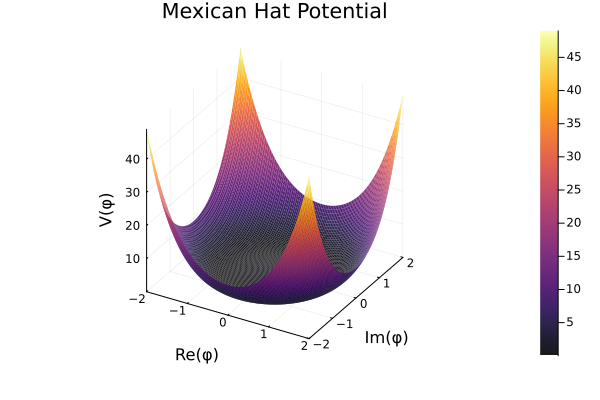

In [7]:
using Plots

# Choose a backend (optional – comment/uncomment as needed)
# plotly()         # interactive, good for exploration
# pyplot()         # static, good for publications
# gr()             # default, fast but sometimes less polished in 3D

# Define the Mexican hat potential: V(φ) = (|φ|² - 1)²
# where φ = x + i*y, so |φ|² = x² + y²
V(x, y) = (x^2 + y^2 - 1)^2

# Create a grid for the real and imaginary parts of φ
# Use enough points to make the surface smooth
n = 100
re = range(-2, 2, length=n)   # Re(φ)
im = range(-2, 2, length=n)   # Im(φ)

# Compute the potential over the grid.
# The comprehension is ordered so that z[j, i] corresponds to im[j] and re[i].
# This matches the convention expected by Plots.surface(x, y, z).
z = [V(r, i) for i in im, r in re]   # size = (length(im), length(re))

# Plot the surface
p = surface(re, im, z,
    xlabel = "Re(φ)",
    ylabel = "Im(φ)",
    zlabel = "V(φ)",
    title = "Mexican Hat Potential",
    camera = (30, 30),           # (azimuth, elevation) in degrees
    colorbar = true,
    legend = false,
    alpha = 0.9                   # slight transparency to see the shape better
)

# Display the plot (in a script, this will open a window)
display(p)